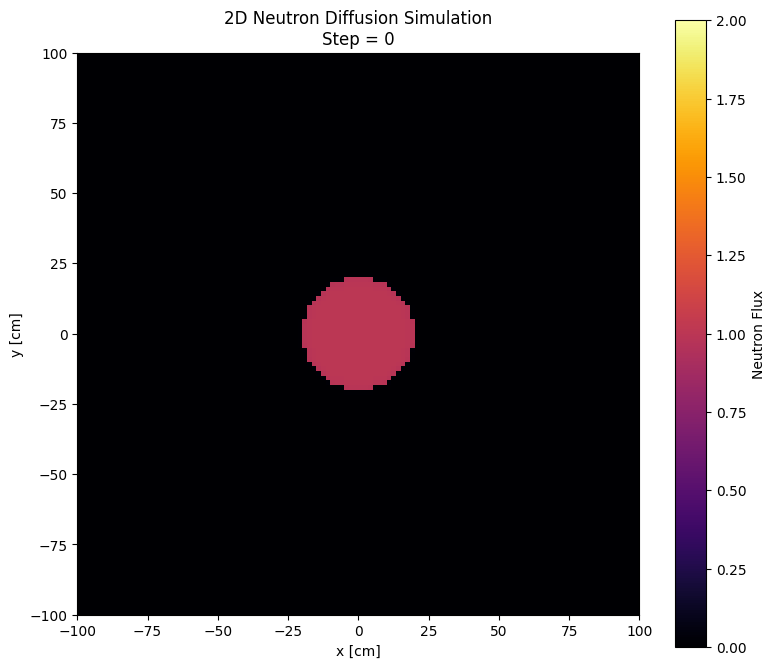

Simulation Completed
Maximum neutron flux : 1.0000
Average neutron flux : 0.0311
Grid size            : 120 x 120
Total iterations     : 700


In [1]:
# ============================================================
# 2D Neutron Diffusion Simulation in a Nuclear Reactor Core
# ============================================================
#
# Author: OpenAI ChatGPT
# Language: Python
# Type: Single executable notebook cell
#
# Description:
# This notebook solves the time-dependent 2D neutron diffusion
# equation using finite differences on a rectangular reactor core.
#
# Features:
# - 2D neutron flux evolution
# - Absorption and fission source terms
# - Explicit finite-difference method
# - Animated neutron flux visualization
# - Reactor material regions
#
# Physics:
#
# ∂φ/∂t = D∇²φ + (νΣ_f - Σ_a)φ + S
#
# where:
#   φ       = neutron flux
#   D       = diffusion coefficient
#   Σ_a     = absorption macroscopic cross section
#   Σ_f     = fission macroscopic cross section
#   ν       = neutrons produced per fission
#   S       = external source
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ------------------------------------------------------------
# Simulation Parameters
# ------------------------------------------------------------

Nx = 120                # Grid points in x
Ny = 120                # Grid points in y

Lx = 200.0              # Core width [cm]
Ly = 200.0              # Core height [cm]

dx = Lx / Nx
dy = Ly / Ny

dt = 0.01               # Time step
steps = 700             # Number of iterations

# ------------------------------------------------------------
# Nuclear Parameters
# ------------------------------------------------------------

# Diffusion coefficient [cm]
D = 1.2

# Macroscopic absorption cross section
Sigma_a = 0.08

# Macroscopic fission cross section
Sigma_f = 0.10

# Average neutrons per fission
nu = 2.4

# Effective multiplication factor term
production = nu * Sigma_f - Sigma_a

# ------------------------------------------------------------
# Create Spatial Grid
# ------------------------------------------------------------

x = np.linspace(-Lx/2, Lx/2, Nx)
y = np.linspace(-Ly/2, Ly/2, Ny)

X, Y = np.meshgrid(x, y)

# ------------------------------------------------------------
# Initialize Neutron Flux
# ------------------------------------------------------------

phi = np.zeros((Ny, Nx))

# Initial neutron source in center
r0 = 20.0
source_region = X**2 + Y**2 < r0**2

phi[source_region] = 1.0

# ------------------------------------------------------------
# Material Regions
# ------------------------------------------------------------

# Create radial regions to mimic fuel/moderator structure

R = np.sqrt(X**2 + Y**2)

D_map = D * np.ones_like(phi)
Sigma_a_map = Sigma_a * np.ones_like(phi)
production_map = production * np.ones_like(phi)

# Outer reflector region
reflector = R > 70

D_map[reflector] = 1.8
Sigma_a_map[reflector] = 0.02
production_map[reflector] = -0.01

# ------------------------------------------------------------
# Laplacian Operator
# ------------------------------------------------------------

def laplacian(Z):

    Ztop    = np.roll(Z, -1, axis=0)
    Zbottom = np.roll(Z, 1, axis=0)
    Zleft   = np.roll(Z, -1, axis=1)
    Zright  = np.roll(Z, 1, axis=1)

    lap = (
        (Zleft + Zright - 2 * Z) / dx**2 +
        (Ztop + Zbottom - 2 * Z) / dy**2
    )

    return lap

# ------------------------------------------------------------
# Boundary Conditions
# Vacuum boundary => zero flux at edges
# ------------------------------------------------------------

def apply_boundary(Z):

    Z[0, :] = 0
    Z[-1, :] = 0
    Z[:, 0] = 0
    Z[:, -1] = 0

    return Z

# ------------------------------------------------------------
# Visualization Setup
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    phi,
    cmap='inferno',
    origin='lower',
    extent=[-Lx/2, Lx/2, -Ly/2, Ly/2],
    vmin=0,
    vmax=2
)

cbar = plt.colorbar(im)
cbar.set_label("Neutron Flux")

ax.set_title("2D Neutron Diffusion Simulation")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")

# ------------------------------------------------------------
# Time Evolution Function
# ------------------------------------------------------------

def update(frame):

    global phi

    lap_phi = laplacian(phi)

    # Neutron diffusion equation
    dphi_dt = (
        D_map * lap_phi +
        production_map * phi
    )

    phi = phi + dt * dphi_dt

    # Numerical stabilization
    phi = np.clip(phi, 0, None)

    # Apply boundary conditions
    phi = apply_boundary(phi)

    # Normalize for stable visualization
    max_flux = np.max(phi)

    if max_flux > 0:
        phi = phi / max_flux

    im.set_array(phi)

    ax.set_title(
        f"2D Neutron Diffusion Simulation\n"
        f"Step = {frame}"
    )

    return [im]

# ------------------------------------------------------------
# Animation
# ------------------------------------------------------------

anim = FuncAnimation(
    fig,
    update,
    frames=steps,
    interval=30,
    blit=True
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final Flux Statistics
# ------------------------------------------------------------

print("======================================")
print("Simulation Completed")
print("======================================")
print(f"Maximum neutron flux : {phi.max():.4f}")
print(f"Average neutron flux : {phi.mean():.4f}")
print(f"Grid size            : {Nx} x {Ny}")
print(f"Total iterations     : {steps}")
print("======================================")